# Animal-Pose — EDA e treino (bovinos em disco)

Este notebook (1) carrega `keypoints.json` e cruza com `animalpose_image_part2/cow/` para **análise exploratória** do subconjunto local; (2) treina um baseline **PyTorch** com **heatmaps** (ResNet-34 + deconvoluções), conforme o README.


In [8]:
from __future__ import annotations

import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REPO_ROOT = Path(".").resolve()
KEYPOINTS_JSON = REPO_ROOT / "keypoints.json"
COW_IMAGE_DIR = REPO_ROOT / "animalpose_image_part2" / "cow"

rng = random.Random(42)

In [9]:
def load_animal_pose(path: Path) -> dict:
    with path.open(encoding="utf-8") as f:
        return json.load(f)


def filter_cow_annotations_on_disk(data: dict, cow_dir: Path) -> tuple[list[dict], set[str]]:
    """Anotações com category_id cow (5) cujo filename existe em cow_dir."""
    images_map: dict[str, str] = data["images"]
    on_disk = {p.name for p in cow_dir.iterdir() if p.is_file()}
    anns = data["annotations"]
    cow_on = []
    for a in anns:
        if a.get("category_id") != 5:
            continue
        fn = images_map.get(str(a["image_id"]))
        if fn is None:
            continue
        if fn in on_disk:
            cow_on.append(a)
    return cow_on, on_disk


data = load_animal_pose(KEYPOINTS_JSON)
cow_anns, cow_files_on_disk = filter_cow_annotations_on_disk(data, COW_IMAGE_DIR)
categories = {c["id"]: c for c in data["categories"]}
cow_cat = categories[5]
kp_names = cow_cat["keypoints"]
skeleton = cow_cat["skeleton"]

n_images_json = len(data["images"])
n_anns_total = len(data["annotations"])
n_cow_anns_json = sum(1 for a in data["annotations"] if a.get("category_id") == 5)

print(f"Imagens referenciadas no JSON: {n_images_json}")
print(f"Anotações totais: {n_anns_total}")
print(f"Anotações de vaca no JSON (todas): {n_cow_anns_json}")
print(f"Arquivos em {COW_IMAGE_DIR.name}/: {len(cow_files_on_disk)}")
print(f"Anotações de vaca com arquivo em disco: {len(cow_anns)}")

Imagens referenciadas no JSON: 4608
Anotações totais: 6117
Anotações de vaca no JSON (todas): 842
Arquivos em cow/: 200
Anotações de vaca com arquivo em disco: 200


## Contagens no dataset completo (JSON) vs. subconjunto em disco

Útil para contextualizar o trabalho: o JSON descreve o pacote completo; as barras à direita refletem apenas o que processamos localmente.

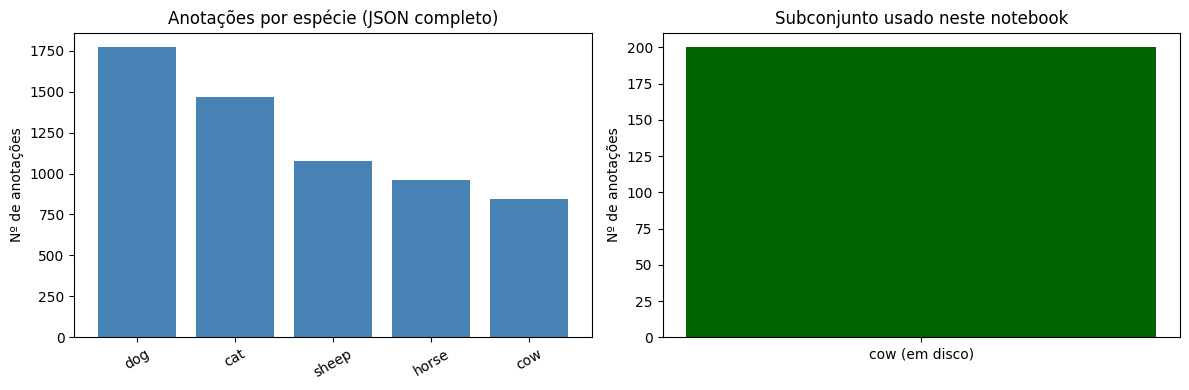

In [10]:
counts_full = Counter(a["category_id"] for a in data["annotations"])
labels = []
full_vals = []
for cid in sorted(counts_full.keys()):
    name = categories[cid]["name"]
    labels.append(name)
    full_vals.append(counts_full[cid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, full_vals, color="steelblue")
axes[0].set_title("Anotações por espécie (JSON completo)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Nº de anotações")

axes[1].bar(["cow (em disco)"], [len(cow_anns)], color="darkgreen")
axes[1].set_title("Subconjunto usado neste notebook")
axes[1].set_ylabel("Nº de anotações")
plt.tight_layout()
plt.show()

## `num_keypoints` e visibilidade por articulação

Cada keypoint vem como `[x, y, v]`. Tratamos `v == 0` como **não anotada/ausente** no rótulo; `v > 0` como presente (o dataset usa principalmente `0` e `1`).

Distribuição de num_keypoints (subconjunto): {20: 200}


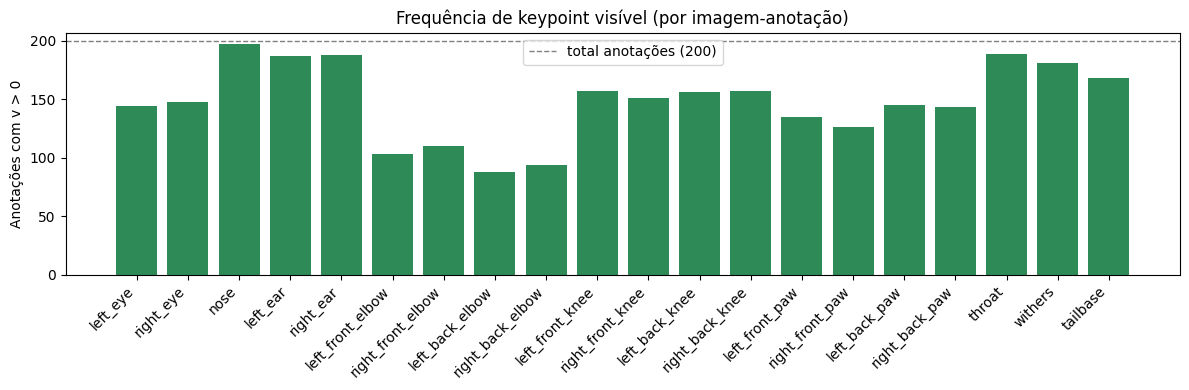

In [11]:
nk = Counter(a["num_keypoints"] for a in cow_anns)
print("Distribuição de num_keypoints (subconjunto):", dict(nk))

visible_per_kp = np.zeros(len(kp_names), dtype=int)
for a in cow_anns:
    for i, (_, _, v) in enumerate(a["keypoints"]):
        if v > 0:
            visible_per_kp[i] += 1

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(kp_names))
ax.bar(x, visible_per_kp, color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(kp_names, rotation=45, ha="right")
ax.set_ylabel("Anotações com v > 0")
ax.set_title("Frequência de keypoint visível (por imagem-anotação)")
ax.axhline(len(cow_anns), color="gray", linestyle="--", linewidth=1, label=f"total anotações ({len(cow_anns)})")
ax.legend()
plt.tight_layout()
plt.show()

## Caixas delimitadoras (`bbox`)

Formato COCO: `[x_min, y_min, largura, altura]` em pixels (coordenadas no espaço da imagem original).

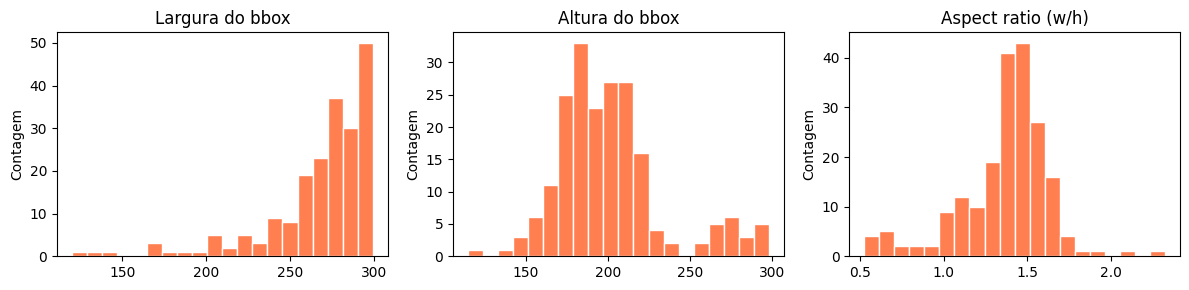

bbox largura: min=120 max=299 mean=267.9
bbox altura: min=115 max=298 mean=201.5
área: min=19800 max=89102 mean=53723.7


In [12]:
widths = np.array([a["bbox"][2] for a in cow_anns])
heights = np.array([a["bbox"][3] for a in cow_anns])
areas = widths * heights
aspect = widths / np.maximum(heights, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(widths, bins=20, color="coral", edgecolor="white")
axes[0].set_title("Largura do bbox")
axes[1].hist(heights, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Altura do bbox")
axes[2].hist(aspect, bins=20, color="coral", edgecolor="white")
axes[2].set_title("Aspect ratio (w/h)")
for ax in axes:
    ax.set_ylabel("Contagem")
plt.tight_layout()
plt.show()

print(
    f"bbox largura: min={widths.min():.0f} max={widths.max():.0f} mean={widths.mean():.1f}\n"
    f"bbox altura: min={heights.min():.0f} max={heights.max():.0f} mean={heights.mean():.1f}\n"
    f"área: min={areas.min():.0f} max={areas.max():.0f} mean={areas.mean():.1f}"
)

## Dimensões reais das imagens (lidas dos arquivos)

O JSON local não inclui `width`/`height` por imagem; medimos com PIL.

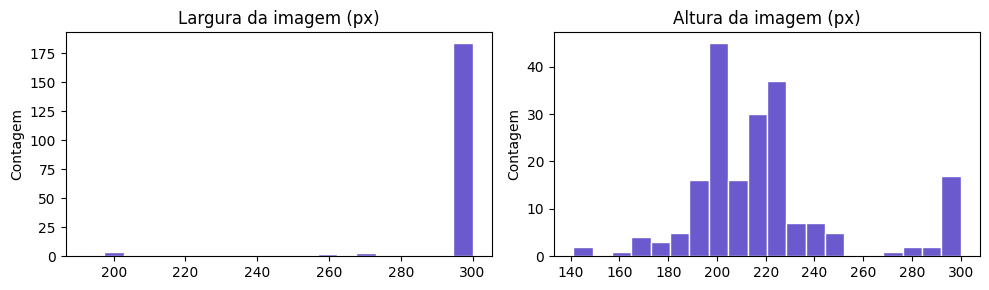

Imagens: largura 192-300 (média 295), altura 141-300 (média 219)


In [13]:
images_map = data["images"]
img_w, img_h = [], []
for a in cow_anns:
    fn = images_map[str(a["image_id"])]
    path = COW_IMAGE_DIR / fn
    with Image.open(path) as im:
        w, h = im.size
    img_w.append(w)
    img_h.append(h)
img_w = np.array(img_w)
img_h = np.array(img_h)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(img_w, bins=20, color="slateblue", edgecolor="white")
axes[0].set_title("Largura da imagem (px)")
axes[1].hist(img_h, bins=20, color="slateblue", edgecolor="white")
axes[1].set_title("Altura da imagem (px)")
for ax in axes:
    ax.set_ylabel("Contagem")
plt.tight_layout()
plt.show()
print(f"Imagens: largura {img_w.min()}-{img_w.max()} (média {img_w.mean():.0f}), altura {img_h.min()}-{img_h.max()} (média {img_h.mean():.0f})")

## Visualização: imagens com keypoints e esqueleto

Arestas do esqueleto só são desenhadas quando **ambos** os pontos têm `v > 0`.

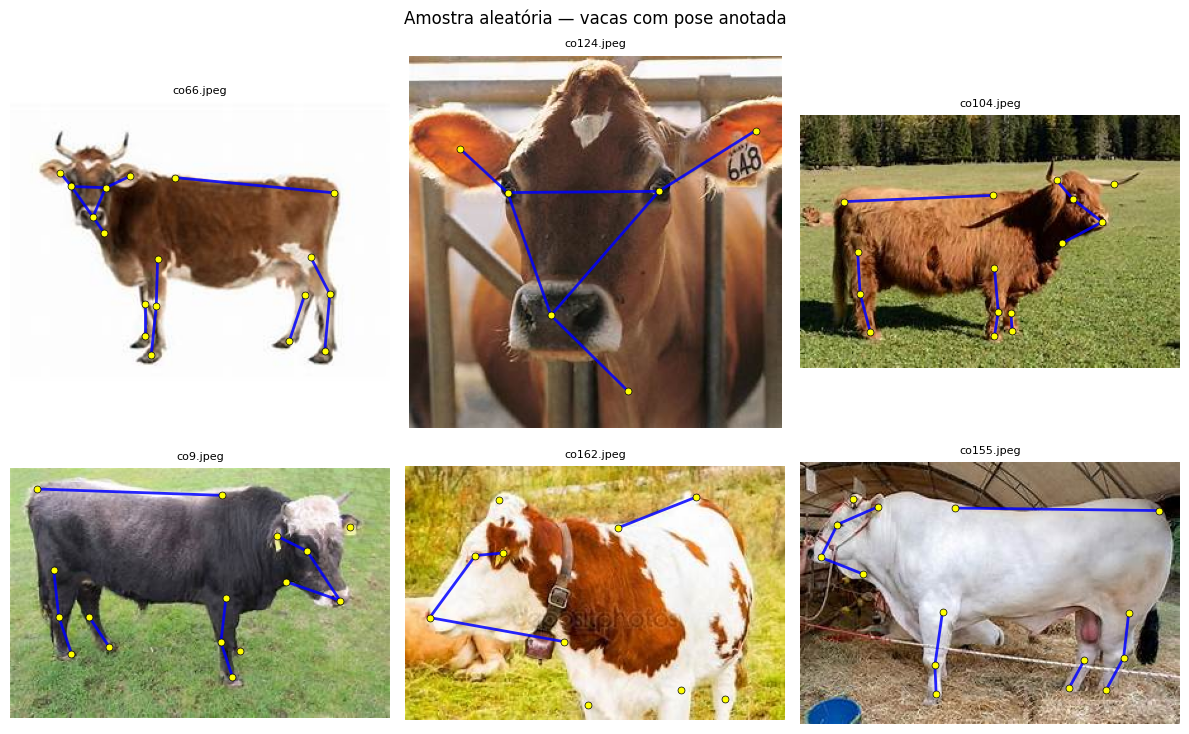

In [14]:
def draw_pose(ax, img_arr: np.ndarray, keypoints: list, skeleton_edges: list[list[int]]):
    ax.imshow(img_arr)
    pts = np.array(keypoints, dtype=float)
    for i, j in skeleton_edges:
        if pts[i, 2] > 0 and pts[j, 2] > 0:
            ax.plot([pts[i, 0], pts[j, 0]], [pts[i, 1], pts[j, 1]], "b-", linewidth=2, alpha=0.85)
    vis = pts[:, 2] > 0
    ax.scatter(pts[vis, 0], pts[vis, 1], c="yellow", s=25, edgecolors="black", linewidths=0.5, zorder=5)
    ax.axis("off")


sample = rng.sample(cow_anns, k=min(6, len(cow_anns)))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for ax, ann in zip(axes, sample):
    fn = images_map[str(ann["image_id"])]
    path = COW_IMAGE_DIR / fn
    with Image.open(path) as im:
        im_rgb = np.array(im.convert("RGB"))
    draw_pose(ax, im_rgb, ann["keypoints"], skeleton)
    ax.set_title(fn, fontsize=8)
plt.suptitle("Amostra aleatória — vacas com pose anotada")
plt.tight_layout()
plt.show()